Environment Setup

In [3]:
# CODE BLOCK 1

!pip install scanpy leidenalg

Importing Libraries Now we import Scanpy and configure its settings. Scanpy functions are divided into three main categories:

sc.pp: Preprocessing (filtering, normalizing)

sc.tl: Tools (running algorithms like PCA, UMAP, clustering)

sc.pl: Plotting (creating visualizations)

In [4]:
# CODE BLOCK 2

import scanpy as sc

import pandas as pd

# Set the figure size and resolution for nice, clear plots in Colab

sc.settings.set_figure_params(dpi=80, facecolor='white')

/tmp/ipykernel_918/1628989691.py:9: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=80, facecolor='white')


Loading the PBMC 3k Dataset

In [5]:
# CODE BLOCK 3

# Download and load the PBMC 3k dataset into the 'adata' variable

adata = sc.datasets.pbmc3k()

# Print the object to see its structure (cells are rows, genes are columns)

print(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


Quality Control (QC) - Tagging Mitochondrial Genes Before we analyze the data, we must filter out dying cells. When a cell membrane breaks, its cytoplasmic RNA leaks out, but the mitochondria (which have their own membranes) remain inside. Therefore, a high percentage of mitochondrial genes is a clear indicator of a dying cell. First, we identify which genes are mitochondrial.

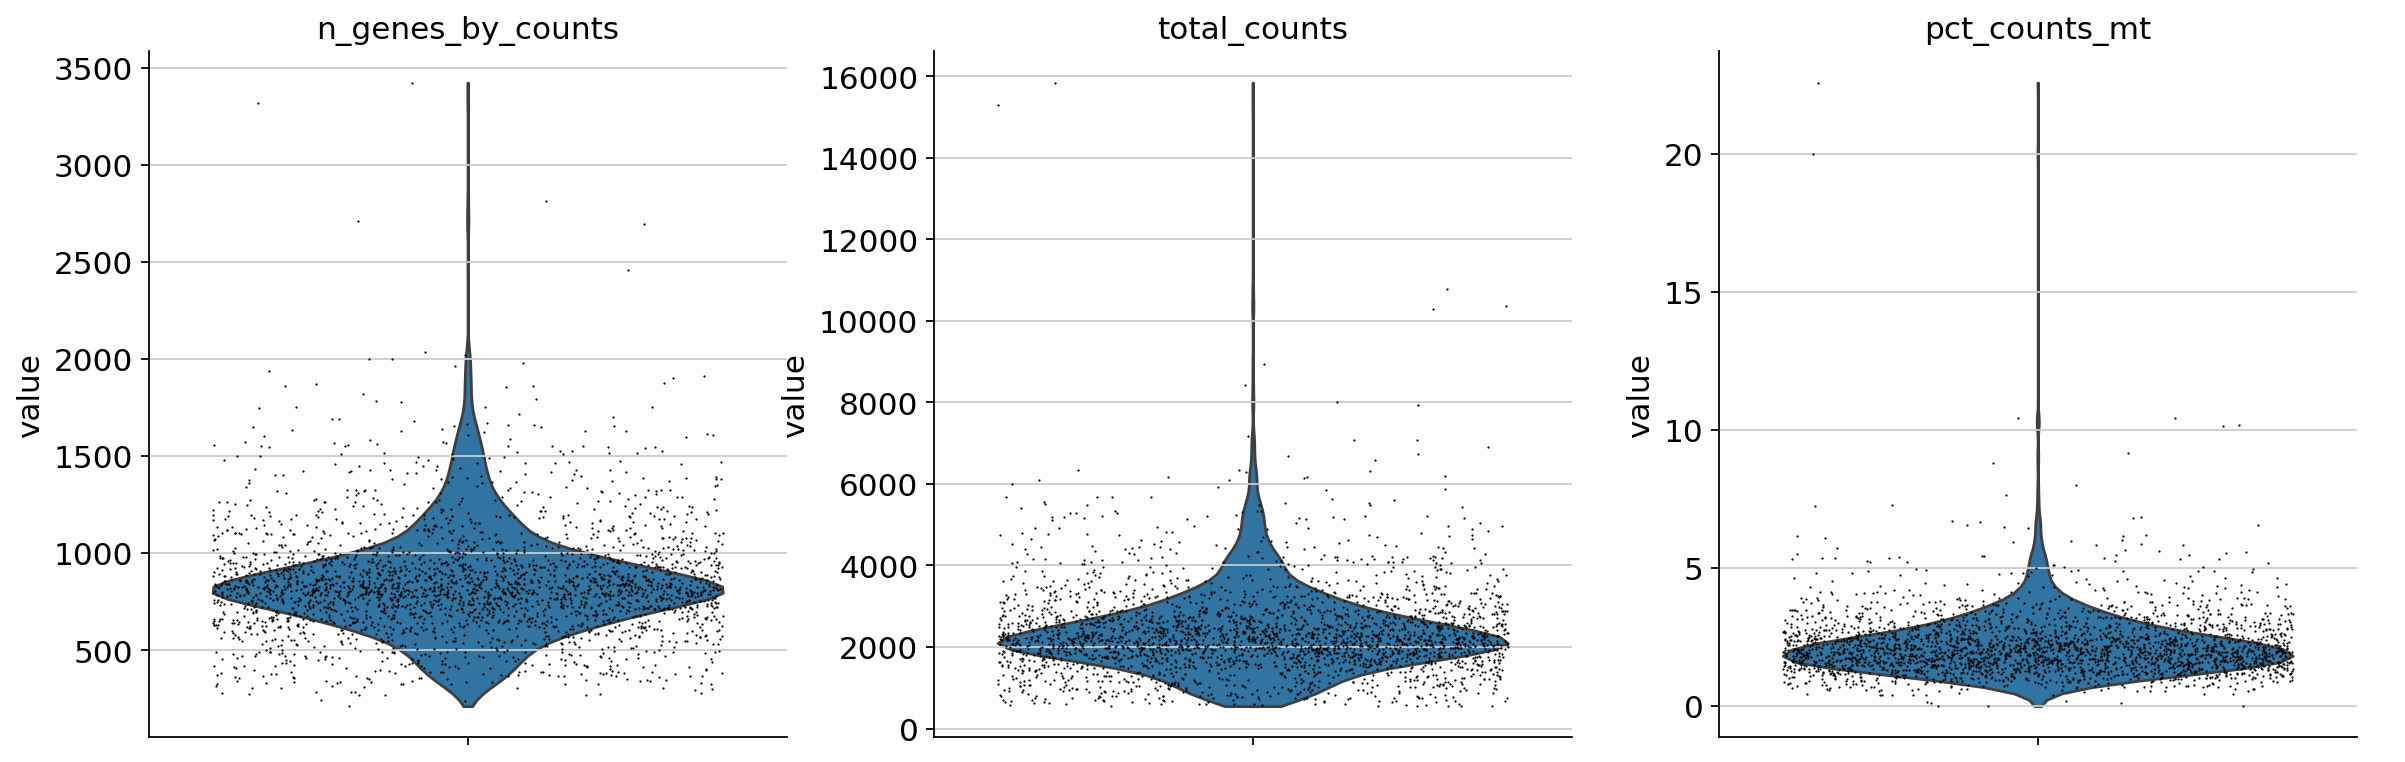

In [6]:
# CODE BLOCK 4

# Create a new column in our gene metadata (adata.var)

# It marks 'True' if the gene name starts with 'MT-' (mitochondrial)

adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics and add them to the cell metadata (adata.obs)

# This calculates total counts, number of genes, and % of mitochondrial counts per cell

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Plot violin plots to visualize the distribution of these metrics

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],

             jitter=0.4, multi_panel=True)

Filtering the Data

In [10]:
# CODE BLOCK 5

# Filter genes: keep only genes expressed in at least 3 cells

sc.pp.filter_genes(adata, min_cells=3)

# Filter cells based on gene count (remove empty droplets and doublets)

sc.pp.filter_cells(adata, min_genes=200)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]

# Filter cells based on mitochondrial percentage (keep cells with less than 5% MT)

adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"After filtering, we have {adata.n_obs} cells and {adata.n_vars} genes left.")

After filtering, we have 2638 cells and 13656 genes left.


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Normalization and Log-Transformation

In [11]:
# CODE BLOCK 6

# Normalize every cell to have 10,000 total counts

sc.pp.normalize_total(adata, target_sum=1e4)

# Apply a log(1 + x) transformation

sc.pp.log1p(adata)

/tmp/ipykernel_918/940300878.py:5: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(adata, target_sum=1e4)


Identifying Highly Variable Genes (HVGs)

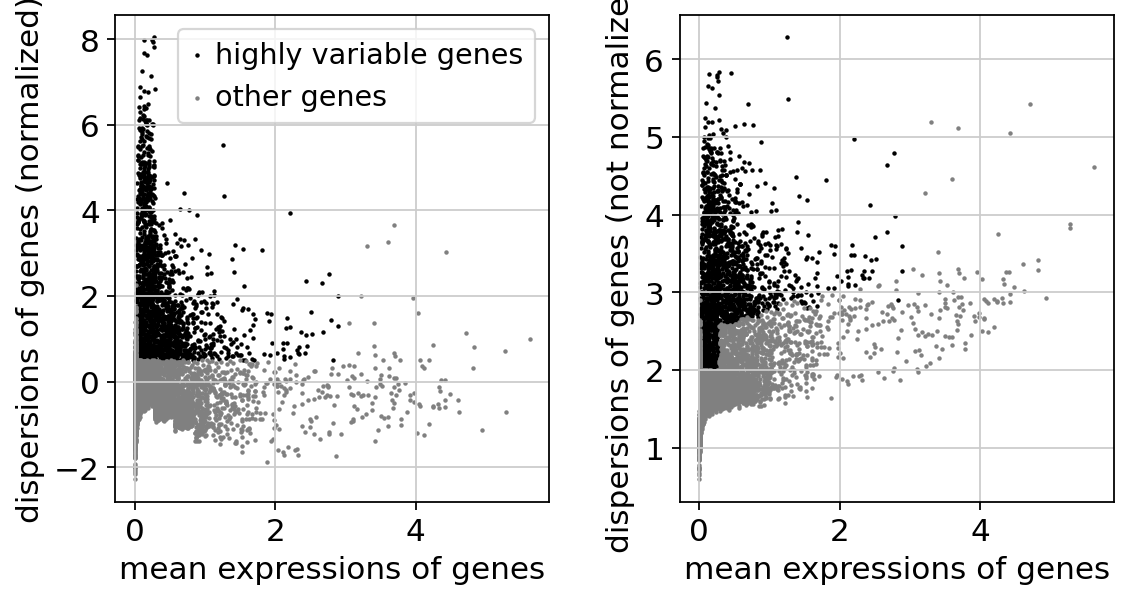

In [12]:
# CODE BLOCK 7

# Identify the highly variable genes

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Plot the genes to see the highly variable ones (they will be highlighted)

sc.pl.highly_variable_genes(adata)

# Keep only the highly variable genes for the rest of the analysis

adata = adata[:, adata.var.highly_variable]

Dimensionality Reduction (PCA)

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


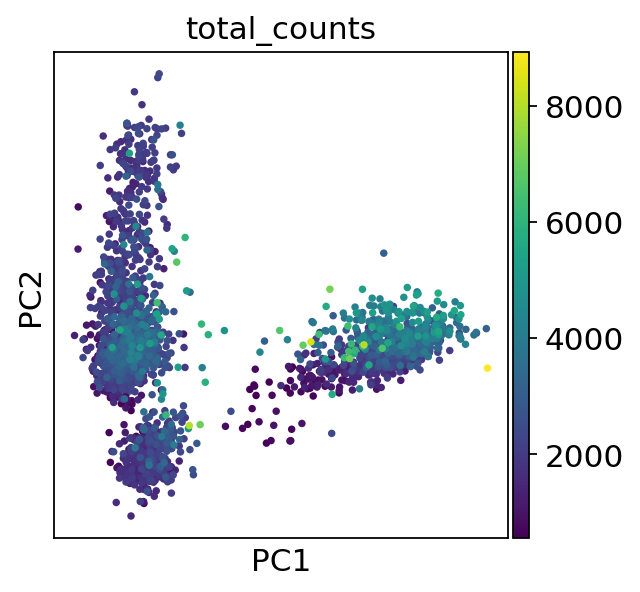

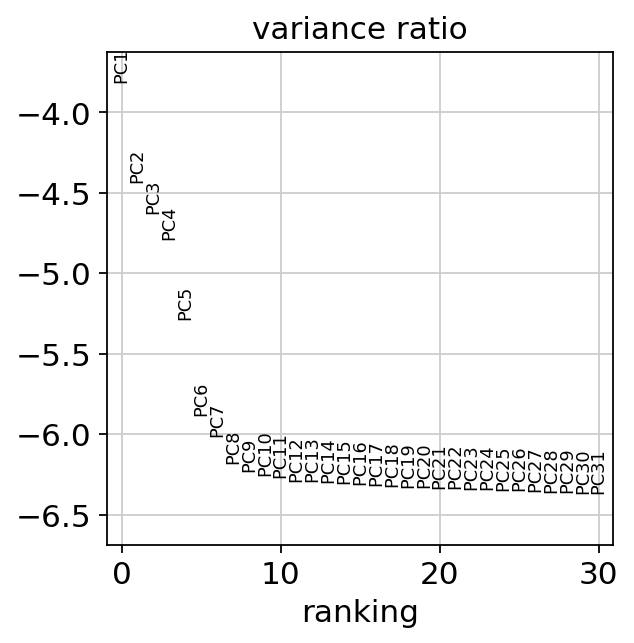

In [13]:
# CODE BLOCK 8

# Scale the data so each gene has equal weight (mean 0, variance 1)

# Max_value=10 clips extreme outliers so they don't dominate the PCA

sc.pp.scale(adata, max_value=10)

# Run PCA (Principal Component Analysis)

sc.tl.pca(adata, svd_solver='arpack')

# 1. Plot PC1 vs PC2

# We color by 'total_counts' to verify that our clusters aren't just

# forming based on how deeply the cells were sequenced.

sc.pl.pca(adata, color='total_counts')

# 2. Plot the 'elbow plot' (Variance explained by each PC)

# Look for where the curve flattens out to decide how many PCs to use

# for the neighborhood graph in the next step (usually between 10 and 50).

sc.pl.pca_variance_ratio(adata, log=True)

Neighborhood Graph and UMAP

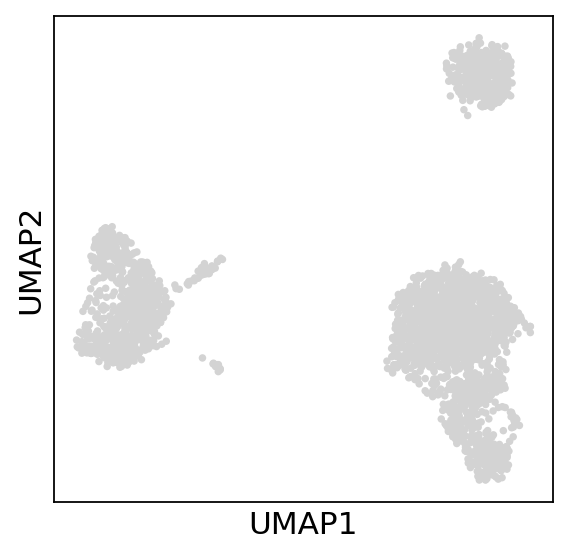

In [14]:
# CODE BLOCK 9

# Compute the neighborhood graph using the top 40 Principal Components

sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# Run UMAP to generate the 2D visualization layout

sc.tl.umap(adata)

# Plot the raw UMAP

sc.pl.umap(adata)

Clustering the Cells

/tmp/ipykernel_918/3332366282.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


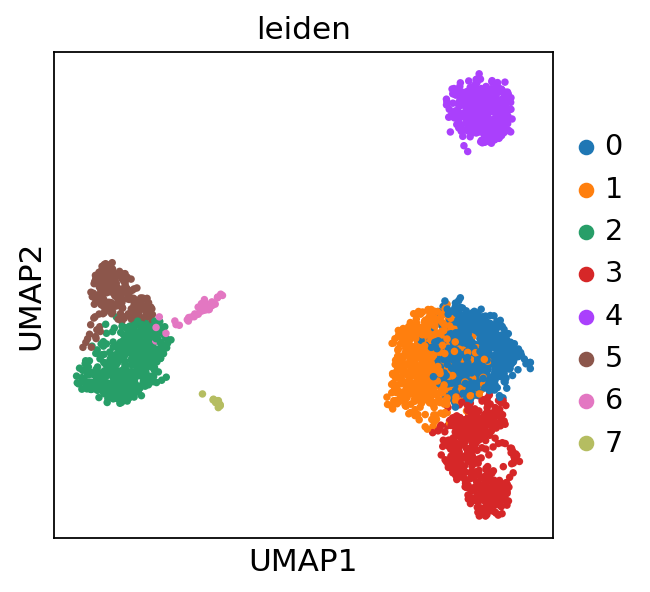

In [15]:
# CODE BLOCK 10

# Run the Leiden clustering algorithm

sc.tl.leiden(adata)

# Plot the UMAP again, but this time color the cells by their Leiden cluster ID

sc.pl.umap(adata, color=['leiden'])